# 1 Exploración de y preparación los datos

## 1.1 Revisión del contenido

In [1]:
#Importar las librarías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import numpy as np

In [2]:
#Leer los archivos csv
visitas = pd.read_csv('/datasets/visits_log_us.csv')
ordenes = pd.read_csv('/datasets/orders_log_us.csv')
costos = pd.read_csv('/datasets/costs_us.csv')


In [3]:
visitas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [4]:
ordenes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [5]:
costos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


In [6]:
visitas.isna().count()

Device       359400
End Ts       359400
Source Id    359400
Start Ts     359400
Uid          359400
dtype: int64

In [7]:
#Verificar si hay valores nulos
print("Valores nulos en visitas:")
print(visitas.isnull().sum())

print("\nValores nulos en ordenes:")
print(ordenes.isnull().sum())

print("\nValores nulos en costos:")
print(costos.isnull().sum())

Valores nulos en visitas:
Device       0
End Ts       0
Source Id    0
Start Ts     0
Uid          0
dtype: int64

Valores nulos en ordenes:
Buy Ts     0
Revenue    0
Uid        0
dtype: int64

Valores nulos en costos:
source_id    0
dt           0
costs        0
dtype: int64


In [8]:
visitas.head()

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [9]:
ordenes.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [10]:
costos.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


## Observaciones:

Los datos están completos (no hay datos ausentes) y tienene los tipos de datos adecuados para trabajar con ellos, a exepción de las fechas, que deberán convertirse a tipo fecha.

## 1.2 Preparación de los datos

In [11]:
# Convertir los encabezados a minúsculas
visitas.columns = visitas.columns.str.lower()
ordenes.columns = ordenes.columns.str.lower()
costos.columns = costos.columns.str.lower()

In [12]:
# Reemplazar espacios por guiones bajos en los nombres de las columnas
visitas.columns = visitas.columns.str.replace(' ', '_')
ordenes.columns = ordenes.columns.str.replace(' ', '_')
costos.columns = costos.columns.str.replace(' ', '_')

In [13]:
# Verificar los cambios en los nombres de columnas
print("Columnas de visitas:")
print(visitas.columns)

print("\nColumnas de ordenes:")
print(ordenes.columns)

print("\nColumnas de costos:")
print(costos.columns)

Columnas de visitas:
Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')

Columnas de ordenes:
Index(['buy_ts', 'revenue', 'uid'], dtype='object')

Columnas de costos:
Index(['source_id', 'dt', 'costs'], dtype='object')


In [14]:
#Convertir las fechas a tipo fecha
visitas['start_ts'] = pd.to_datetime(visitas['start_ts'])
visitas['end_ts'] = pd.to_datetime(visitas['end_ts'])
ordenes['buy_ts'] = pd.to_datetime(ordenes['buy_ts'])
costos['dt'] = pd.to_datetime(costos['dt'])

In [15]:
# Verificar los tipos de datos después de la conversión
print("Tipos de datos en visitas:")
print(visitas.dtypes)

print("\nTipos de datos en ordenes:")
print(ordenes.dtypes)

print("\nTipos de datos en costos:")
print(costos.dtypes)

Tipos de datos en visitas:
device               object
end_ts       datetime64[ns]
source_id             int64
start_ts     datetime64[ns]
uid                  uint64
dtype: object

Tipos de datos en ordenes:
buy_ts     datetime64[ns]
revenue           float64
uid                uint64
dtype: object

Tipos de datos en costos:
source_id             int64
dt           datetime64[ns]
costs               float64
dtype: object


# 2 Métricas e informes

## 2.1 Visitas

### 2.1.1 ¿Cuántas personas lo usan cada día, semana y mes?

In [16]:
# Calcular usuarios únicos por día
visitas_diarias = visitas.groupby(visitas['start_ts'].dt.date)['uid'].nunique().reset_index()
visitas_diarias.columns = ['fecha', 'usuarios']

# Calcular usuarios únicos por semana
visitas_semanales = visitas.groupby(visitas['start_ts'].dt.isocalendar().week)['uid'].nunique().reset_index()
visitas_semanales.columns = ['semana', 'usuarios']

# Calcular usuarios únicos por mes
visitas_mensuales = visitas.groupby(visitas['start_ts'].dt.to_period('M'))['uid'].nunique().reset_index()
visitas_mensuales.columns = ['mes', 'usuarios']

In [17]:
# Mostrar los datos agrupados
print("Usuarios únicos por día:")
print(visitas_diarias.head())

print("\nUsuarios únicos por semana:")
print(visitas_semanales.head())

print("\nUsuarios únicos por mes:")
print(visitas_mensuales.head())

Usuarios únicos por día:
        fecha  usuarios
0  2017-06-01       605
1  2017-06-02       608
2  2017-06-03       445
3  2017-06-04       476
4  2017-06-05       820

Usuarios únicos por semana:
   semana  usuarios
0       1      6918
1       2      6703
2       3      6972
3       4      7060
4       5      8111

Usuarios únicos por mes:
       mes  usuarios
0  2017-06     13259
1  2017-07     14183
2  2017-08     11631
3  2017-09     18975
4  2017-10     29692


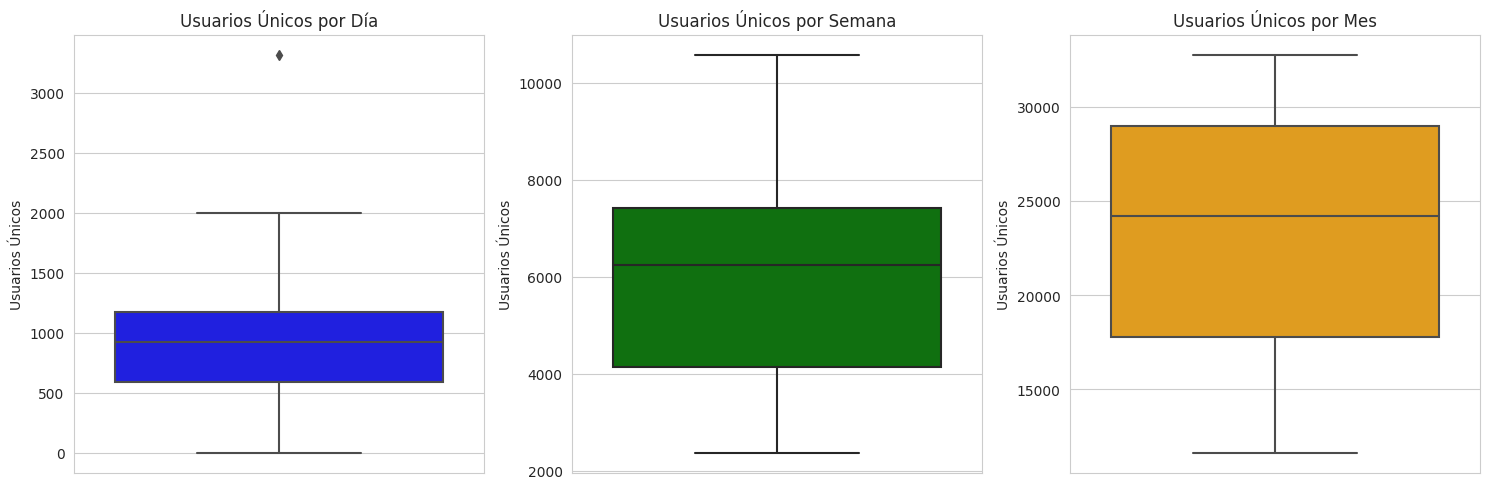

In [18]:
# Configurar el estilo de los gráficos
sns.set_style("whitegrid")

# Crear figura con subplots
plt.figure(figsize=(15, 5))

# Diagrama de cajas para visitas diarias
plt.subplot(1, 3, 1)
sns.boxplot(data=visitas_diarias, y='usuarios', color = "blue")
plt.title('Usuarios Únicos por Día')
plt.ylabel('Usuarios Únicos')

# Diagrama de cajas para visitas semanales
plt.subplot(1, 3, 2)
sns.boxplot(data=visitas_semanales, y='usuarios', color = "green")
plt.title('Usuarios Únicos por Semana')
plt.ylabel('Usuarios Únicos')

# Diagrama de cajas para visitas mensuales
plt.subplot(1, 3, 3)
sns.boxplot(data=visitas_mensuales, y='usuarios', color = "orange")
plt.title('Usuarios Únicos por Mes')
plt.ylabel('Usuarios Únicos')

# Ajustar el diseño para evitar superposición
plt.tight_layout()

# Mostrar los gráficos
plt.show()

In [19]:
#Datos estadísticos
print("Usuarios únicos por día:")
print(visitas_diarias['usuarios'].describe())

print("\nUsuarios únicos por semana:")
print(visitas_semanales['usuarios'].describe())

print("\nUsuarios únicos por mes:")
print(visitas_mensuales['usuarios'].describe())

Usuarios únicos por día:
count     364.000000
mean      907.991758
std       370.513838
min         1.000000
25%       594.000000
50%       921.000000
75%      1173.000000
max      3319.000000
Name: usuarios, dtype: float64

Usuarios únicos por semana:
count       52.000000
mean      5825.288462
std       2004.308969
min       2364.000000
25%       4128.750000
50%       6233.000000
75%       7420.750000
max      10586.000000
Name: usuarios, dtype: float64

Usuarios únicos por mes:
count       12.000000
mean     23228.416667
std       7546.380462
min      11631.000000
25%      17777.000000
50%      24240.500000
75%      28984.750000
max      32797.000000
Name: usuarios, dtype: float64


### Obervaciones:

- Se tienen 900 usuarios en promedio al día. Un mínimo de 1 y un máximo usual de 2000.
- A la semana, la cifra promedio es de 5800. Un mínimo de 2300 y un máximo usual de 10500
- Y al mes, asciende a más de 23000 usuarios en promedio. Un mínimo de 11600 y un máximo usual de 32800

### 2.1.2 ¿Cuántas sesiones hay por día?

In [20]:
#Sesiones de usuario por día
sesiones_diarias = visitas.groupby(visitas['start_ts'].dt.date).size().reset_index()
sesiones_diarias.columns = ['fecha', 'sesiones']

In [21]:
#Mostras las primeras 10 sesiones
sesiones_diarias.head(10)

,fecha,sesiones
0,2017-06-01,664
1,2017-06-02,658
2,2017-06-03,477
3,2017-06-04,510
4,2017-06-05,893
5,2017-06-06,875
6,2017-06-07,788
7,2017-06-08,939
8,2017-06-09,755
9,2017-06-10,375


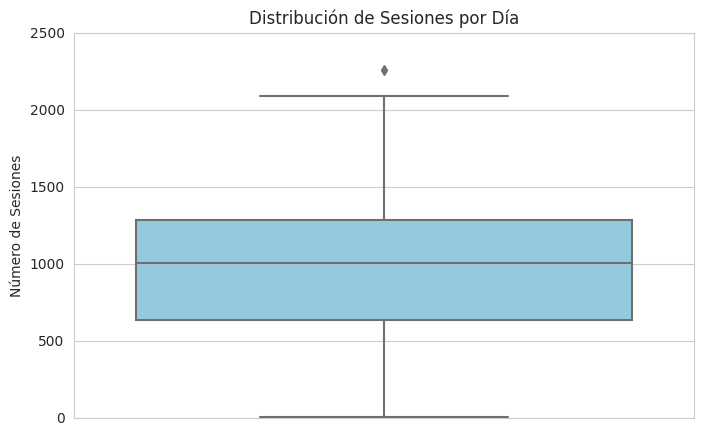

In [22]:
# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura para el diagrama de caja
plt.figure(figsize=(8, 5))

# Diagrama de caja para sesiones diarias
sns.boxplot(data=sesiones_diarias, y='sesiones', color = "skyblue")
plt.title('Distribución de Sesiones por Día')
plt.ylabel('Número de Sesiones')
plt.ylim(0, 2500) 

# Mostrar el gráfico
plt.show()

In [23]:
#Datos estadísticos
print("Sesiones por día:")
sesiones_diarias.describe()

Sesiones por día:


,sesiones
count,364.000000
mean,987.362637
std,418.994796
min,1.000000
25%,635.500000
50%,1003.000000
75%,1280.000000
max,4042.000000


### Observaciones:

- Hay un promedio de cerca de 1000 sesiones al día.
- Un mínimo de 1 sesión.
- Y un máximo usual de más de 2000 sesiones.

### 2.1.3 ¿Cuál es la duración de cada sesión?

In [24]:
#Duración de las sesiones
visitas["duracion_sesion_seg"] = (visitas["end_ts"] - visitas["start_ts"]).dt.total_seconds()
visitas

,device,end_ts,source_id,start_ts,uid,duracion_sesion_seg
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,1080.0
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,1680.0
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,0.0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,1440.0
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,0.0
...,...,...,...,...,...,...
359395,desktop,2017-07-29 19:07:19,2,2017-07-29 19:07:00,18363291481961487539,19.0
359396,touch,2018-01-25 17:38:19,1,2018-01-25 17:38:00,18370831553019119586,19.0
359397,desktop,2018-03-03 10:12:19,4,2018-03-03 10:12:00,18387297585500748294,19.0
359398,desktop,2017-11-02 10:12:19,5,2017-11-02 10:12:00,18388616944624776485,19.0


In [25]:
visitas['duracion_sesion_seg'].sort_values(ascending=False)

229891    42660.0
177381    35760.0
248062    32880.0
1197      32520.0
221945    31440.0
           ...   
140438        0.0
179498        0.0
97645         0.0
4181      -1920.0
177972    -2760.0
Name: duracion_sesion_seg, Length: 359400, dtype: float64

In [26]:
# Identificar registros con duración negativa
duraciones_negativas = visitas[visitas['duracion_sesion_seg'] < 0]

# Mostrar los registros con duración negativa
print("Registros con duración negativa:")
print(duraciones_negativas[['uid', 'start_ts', 'end_ts', 'duracion_sesion_seg']])

# Contar el número de registros con duración negativa
print("\nNúmero de registros con duración negativa:", len(duraciones_negativas))

Registros con duración negativa:
                         uid            start_ts              end_ts  \
4181    13092152539246794986 2018-03-25 03:50:00 2018-03-25 03:18:00   
177972   4621202742905035453 2018-03-25 03:55:00 2018-03-25 03:09:00   

        duracion_sesion_seg  
4181                -1920.0  
177972              -2760.0  

Número de registros con duración negativa: 2


In [27]:
# Eliminar registros con duración negativa
visitas = visitas[visitas['duracion_sesion_seg'] >= 0]

# Verificar que no queden duraciones negativas
print("Número de registros con duración negativa después de la limpieza:", 
      len(visitas[visitas['duracion_sesion_seg'] < 0]))

Número de registros con duración negativa después de la limpieza: 0


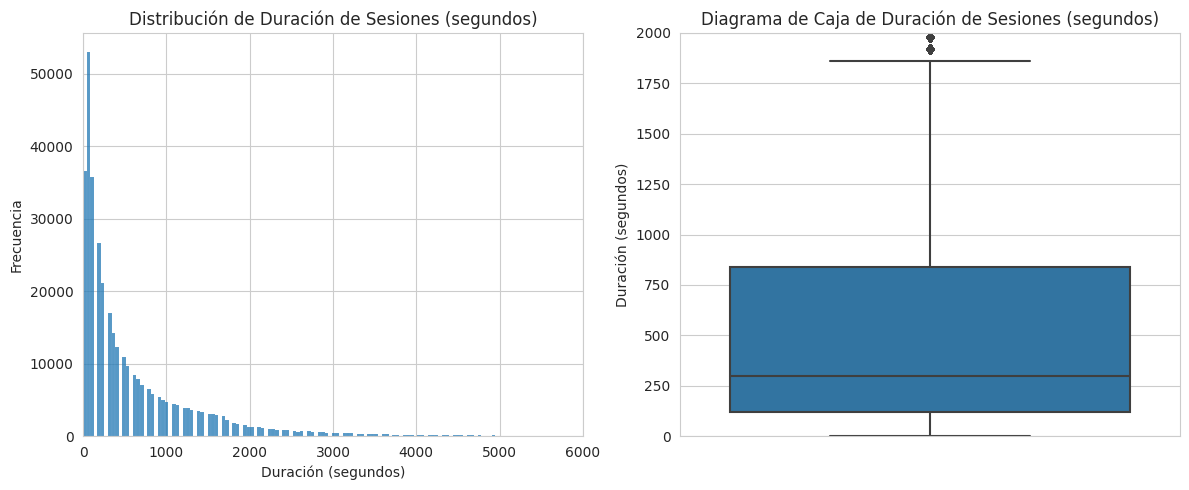

In [28]:
# Configurar el estilo de los gráficos
sns.set_style("whitegrid")

# Crear figura con subplots
plt.figure(figsize=(12, 5))

# Histograma para duración de sesiones
plt.subplot(1, 2, 1)
sns.histplot(data=visitas, x='duracion_sesion_seg', bins=1000)
plt.title('Distribución de Duración de Sesiones (segundos)')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.xlim(0, 6000)

# Diagrama de caja para duración de sesiones
plt.subplot(1, 2, 2)
sns.boxplot(data=visitas, y='duracion_sesion_seg')
plt.title('Diagrama de Caja de Duración de Sesiones (segundos)')
plt.ylabel('Duración (segundos)')
plt.ylim(0, 2000)

# Ajustar el diseño para evitar superposición
plt.tight_layout()

# Mostrar los gráficos
plt.show()

In [29]:
#Datos estadísticos
print("Datos esta´disticos de la duración de las sesiones")
visitas["duracion_sesion_seg"].describe()

Datos esta´disticos de la duración de las sesiones


count    359398.000000
mean        643.042287
std         997.105212
min           0.000000
25%         120.000000
50%         300.000000
75%         840.000000
max       42660.000000
Name: duracion_sesion_seg, dtype: float64

In [30]:
#Filtrar las sesiones que duran cero segundos
zero_sec_sessions = visitas[visitas["duracion_sesion_seg"] == 0]
#Contar la cantidad de sesiones con cero segundos de duración
num_zero_sec_sessions = len(zero_sec_sessions)
print(num_zero_sec_sessions)

35794


In [31]:
#Filtrar las sesiones por duración > 0 segundos
duraciones_filtradas = visitas[visitas["duracion_sesion_seg"] > 0]
duraciones_filtradas['duracion_sesion_seg'].sort_values(ascending=False)

229891    42660.0
177381    35760.0
248062    32880.0
1197      32520.0
221945    31440.0
           ...   
358824       19.0
358825       19.0
358826       19.0
358827       19.0
359399       19.0
Name: duracion_sesion_seg, Length: 323604, dtype: float64

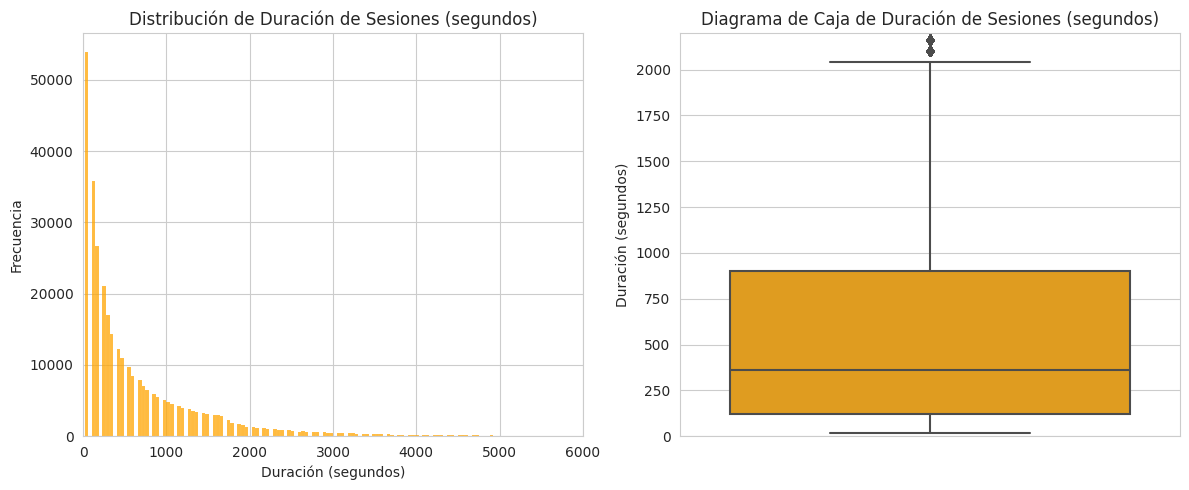

In [32]:
# Configurar el estilo de los gráficos
sns.set_style("whitegrid")

# Crear figura con subplots
plt.figure(figsize=(12, 5))

# Histograma para duración de sesiones
plt.subplot(1, 2, 1)
sns.histplot(data=duraciones_filtradas, x='duracion_sesion_seg', bins=1000, color = "orange")
plt.title('Distribución de Duración de Sesiones (segundos)')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.xlim(0, 6000)

# Diagrama de caja para duración de sesiones
plt.subplot(1, 2, 2)
sns.boxplot(data=duraciones_filtradas, y='duracion_sesion_seg', color = "orange")
plt.title('Diagrama de Caja de Duración de Sesiones (segundos)')
plt.ylabel('Duración (segundos)')
plt.ylim(0, 2200)

# Ajustar el diseño para evitar superposición
plt.tight_layout()

# Mostrar los gráficos
plt.show()

In [33]:
#Datos estadísticos de sesiones con duración > 0 segundos
print("Datos esta´disticos de la duración de las sesiones mayores a cero segundos")
duraciones_filtradas['duracion_sesion_seg'].describe()

Datos esta´disticos de la duración de las sesiones mayores a cero segundos


count    323604.000000
mean        714.169516
std        1026.349417
min          19.000000
25%         120.000000
50%         360.000000
75%         900.000000
max       42660.000000
Name: duracion_sesion_seg, dtype: float64

### Observaciones:

- Casi 36000 sesiones tienen una duración de cero segundos, por lo que se puede decir que esas 36 mil no se iniciaron en realidad.
- Quitando las sesiones con cero segundos de duración, se tiene un promedio de 715 segundos por sesión (casi 12 minutos).
- Un máximo usual de algo más de 2000 segundos (más de media hora).
- Y un mínimo de 19 segundos.

### 2.1.4 ¿Con qué frecuencia los usuarios regresan?

In [34]:
# Calcular el número de sesiones por usuario
sesiones_por_usuario = visitas.groupby('uid').size().reset_index()
sesiones_por_usuario.columns = ['uid', 'num_sesiones']
sesiones_por_usuario.head()

,uid,num_sesiones
0,11863502262781,1
1,49537067089222,1
2,297729379853735,1
3,313578113262317,3
4,325320750514679,2


In [35]:
# Filtrar usuarios con más de una sesión para analizar retornos
usuarios_recurrentes = sesiones_por_usuario[sesiones_por_usuario['num_sesiones'] > 1]

In [36]:
# Calcular el intervalo promedio entre sesiones para usuarios recurrentes
def intervalo_entre_sesiones(df, user_id):
    user_visits = df[df['uid'] == user_id][['start_ts']].sort_values('start_ts')
    intervals = user_visits['start_ts'].diff().dropna().dt.total_seconds() / (24 * 3600)  # Convertir a días
    return intervals.mean() if not intervals.empty else None

In [37]:
# Aplicar la función para cada usuario recurrente
intervalos = []
for uid in usuarios_recurrentes['uid']:
    intervalo = intervalo_entre_sesiones(visitas, uid)
    if intervalo is not None:
        intervalos.append({'uid': uid, 'intervalo_promedio_dias': intervalo})

intervalos_df = pd.DataFrame(intervalos)

In [38]:
# Mostrar estadísticas generales
sesiones_por_usuario['num_sesiones'].describe()

count    228169.000000
mean          1.575139
std           4.646787
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         893.000000
Name: num_sesiones, dtype: float64

In [39]:
usuarios_recurrentes['num_sesiones'].describe()

count    52128.000000
mean         3.517438
std          9.467026
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max        893.000000
Name: num_sesiones, dtype: float64

In [40]:
intervalos_df['intervalo_promedio_dias'].describe()

count    52128.000000
mean        41.118310
std         55.967433
min          0.000000
25%          2.194271
50%         19.091319
75%         57.027604
max        361.530556
Name: intervalo_promedio_dias, dtype: float64

In [41]:
print("Sesiones por usuario:")
sesiones_por_usuario.sort_values(by='num_sesiones', ascending=False)

Sesiones por usuario:


,uid,num_sesiones
159301,12869801667763685675,893
40367,3263486045884611639,615
139405,11255648391090536411,551
210837,17030528792926543083,357
99840,8056418121947262981,343
...,...,...
86015,6941514512558303452,1
86016,6941551041544435874,1
86018,6941737448038189076,1
86019,6941739342632742691,1


In [42]:
print("Intervalos promedio entre sesiones:")
intervalos_df.sort_values(by='intervalo_promedio_dias', ascending=True)

Intervalos promedio entre sesiones:


,uid,intervalo_promedio_dias
5712,1981020429381477763,0.000000
16019,5611876390321690831,0.000694
41178,14521997987159797110,0.000694
2050,709136272518592614,0.000694
21794,7659047713736155838,0.001389
...,...,...
31453,11090956117380600507,357.996528
28168,9938646605618948329,358.859028
15455,5409575498884294658,359.147917
17492,6132343543490124620,360.008333


In [43]:
# Clasificar a los usuarios
def clasificar_usuario(dias):
    if dias <= 1:  # Cerca del mínimo o 1 día
        return 'Visitante muy frecuente (≤1 día)'
    elif dias <= 7:  # Aproximadamente el percentil 25
        return 'Visitante frecuente (1-7 días)'
    elif dias <= 30:  # Aproximadamente el percentil 50 (mediana)
        return 'Visitante regular (7-30 días)'
    else:  # Más allá del percentil 75
        return 'Visitante ocasional (>30 días)'

In [44]:
# Aplicar la clasificación a intervalos_df
intervalos_df['categoria'] = intervalos_df['intervalo_promedio_dias'].apply(clasificar_usuario)

In [45]:
intervalos_df

,uid,intervalo_promedio_dias,categoria
0,313578113262317,86.886806,Visitante ocasional (>30 días)
1,325320750514679,148.919444,Visitante ocasional (>30 días)
2,526778907996220,55.924769,Visitante ocasional (>30 días)
3,577434573913691,6.161806,Visitante frecuente (1-7 días)
4,1260655184775459,43.325000,Visitante ocasional (>30 días)
...,...,...,...
52123,18445884613277162497,25.512500,Visitante regular (7-30 días)
52124,18446104389491815722,0.629861,Visitante muy frecuente (≤1 día)
52125,18446156210226471712,18.163773,Visitante regular (7-30 días)
52126,18446167067214817906,0.004861,Visitante muy frecuente (≤1 día)


In [46]:
# Mostrar distribución de categorías
print("\nDistribución de categorías de usuarios:")
intervalos_df['categoria'].value_counts()


Distribución de categorías de usuarios:


Visitante ocasional (>30 días)      21139
Visitante regular (7-30 días)       12508
Visitante muy frecuente (≤1 día)    10098
Visitante frecuente (1-7 días)       8383
Name: categoria, dtype: int64

In [47]:
#Usuarios con una sola visita
print("Usuarios que sólo hicieron una visita")
one_visit_count = sesiones_por_usuario[sesiones_por_usuario['num_sesiones'] == 1]['num_sesiones'].count()
one_visit_count

Usuarios que sólo hicieron una visita


176041

In [48]:
# Crear un dataframe para almacenar el cantidad de usuarios por categoría
categorias_dist = intervalos_df['categoria'].value_counts().reset_index()
categorias_dist.columns = ['categoria', 'conteo']

# Agregar la categoría de usuarios con una sola visita
one_visit_data = pd.DataFrame({'categoria': ['Usuarios con una sola visita'], 'conteo': [176041]})
categorias_dist = pd.concat([categorias_dist, one_visit_data], ignore_index=True)

# Ordenar las categorías por conteo (de mayor a menor) para mejor visualización
categorias_dist = categorias_dist.sort_values('conteo', ascending=False)

In [49]:
# Calcular el total de usuarios
total_usuarios = categorias_dist['conteo'].sum()

# Calcular el porcentaje para cada categoría
categorias_dist['porcentaje'] = (categorias_dist['conteo'] / total_usuarios * 100).round(2)

In [50]:
#Mostrar los datos por categoría
categorias_dist

,categoria,conteo,porcentaje
4,Usuarios con una sola visita,176041,77.15
0,Visitante ocasional (>30 días),21139,9.26
1,Visitante regular (7-30 días),12508,5.48
2,Visitante muy frecuente (≤1 día),10098,4.43
3,Visitante frecuente (1-7 días),8383,3.67


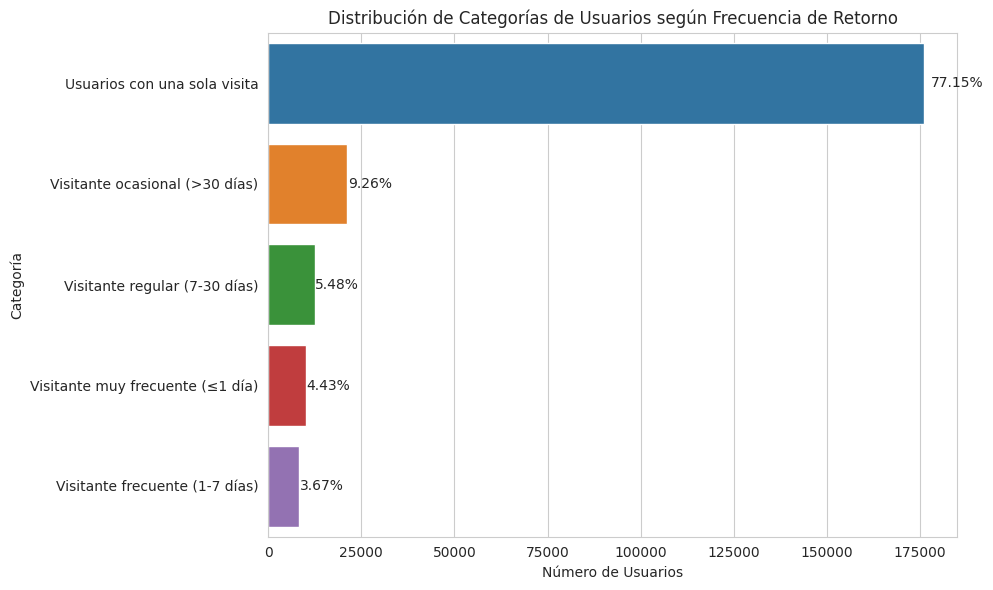

In [51]:
# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura para la gráfica de barras
plt.figure(figsize=(10, 6))

# Gráfica de barras
ax = sns.barplot(data=categorias_dist, x='conteo', y='categoria')

# Agregar porcentajes en las barras
for i, row in enumerate(categorias_dist.itertuples()):
    ax.text(row.conteo * 1.01, i, f'{row.porcentaje}%', va='center', ha='left')

# Configurar título y etiquetas
plt.title('Distribución de Categorías de Usuarios según Frecuencia de Retorno')
plt.xlabel('Número de Usuarios')
plt.ylabel('Categoría')

# Ajustar el diseño para evitar superposición
plt.tight_layout()

# Mostrar el gráfico
plt.show()

### Observaciones:

- Hasta un 77% de los usuarios, hacen una sola visita.
- El 33% restante, se distribuye entre visitantes ocacionales (una vez cada 30 días), visitantes regulares (7 a 30 días entre visitas), visitantes muy frecuentes (más de una vez al día) y visitantes frecuentes (1 a 7 días entre visitas).
- Los visitantes ocacionales representan el 9.2% de los usuarios.
- Los visitantes regulares el 5.5%
- Los muy frecuentes el 4.4%
- Y los frecuentes el 3.6%

## 2.2 Ventas

### 2.2.1 ¿Cuándo empieza la gente a comprar?

In [52]:
# Obtener la primera visita por usuario (considerada como registro)
primera_visita = visitas.groupby('uid')['start_ts'].min().reset_index()
primera_visita.columns = ['uid', 'fecha_registro']

# Agregar el source_id de la primera visita
primera_visita_con_source = pd.merge(
    primera_visita,
    visitas[['uid', 'start_ts', 'source_id']],
    left_on=['uid', 'fecha_registro'],
    right_on=['uid', 'start_ts'],
    how='left'
).drop(columns='start_ts')

In [53]:
# Obtener la primera compra por usuario
primera_compra = ordenes.groupby('uid')['buy_ts'].min().reset_index()
primera_compra.columns = ['uid', 'fecha_primera_compra']

# Unir los dataframes para obtener usuarios con visitas y compras
conversiones = pd.merge(primera_visita_con_source, primera_compra, on='uid', how='inner')

In [54]:
# Calcular el tiempo hasta la primera compra
conversiones['dias_hasta_compra'] = (
    conversiones['fecha_primera_compra'] - conversiones['fecha_registro']
).dt.days

In [55]:
# Definir categorías de conversión
def clasificar_conversion(dias):
    if dias == 0:
        return 'Conversión 0d'
    elif dias <= 1:
        return 'Conversión 1d'
    elif dias <= 7:
        return 'Conversión 2-7d'
    elif dias <= 30:
        return 'Conversión 8-30d'
    else:
        return 'Conversión >30d'


In [56]:
conversiones['categoria_conversion'] = conversiones['dias_hasta_compra'].apply(clasificar_conversion)

In [57]:
# Mostrar resultados
print("Distribución de categorías de conversión:")
conversiones['categoria_conversion'].value_counts()

Distribución de categorías de conversión:


Conversión 0d       26363
Conversión >30d      4902
Conversión 8-30d     2178
Conversión 2-7d      2069
Conversión 1d        1011
Name: categoria_conversion, dtype: int64

In [58]:
conversiones

,uid,fecha_registro,source_id,fecha_primera_compra,dias_hasta_compra,categoria_conversion
0,313578113262317,2017-09-18 22:49:00,2,2018-01-03 21:51:00,106,Conversión >30d
1,1575281904278712,2017-06-03 10:13:00,10,2017-06-03 10:13:00,0,Conversión 0d
2,2429014661409475,2017-10-11 17:14:00,3,2017-10-11 18:33:00,0,Conversión 0d
3,2464366381792757,2018-01-27 20:10:00,5,2018-01-28 15:54:00,0,Conversión 0d
4,2551852515556206,2017-11-24 10:14:00,5,2017-11-24 10:14:00,0,Conversión 0d
...,...,...,...,...,...,...
36518,18445147675727495770,2017-08-20 13:30:00,5,2017-11-24 09:03:00,95,Conversión >30d
36519,18445407535914413204,2017-09-22 23:48:00,3,2017-09-22 23:55:00,0,Conversión 0d
36520,18445601152732270159,2017-08-07 11:51:00,2,2018-03-26 22:54:00,231,Conversión >30d
36521,18446156210226471712,2017-11-07 10:01:00,3,2018-02-18 19:34:00,103,Conversión >30d


<Figure size 1000x600 with 0 Axes>

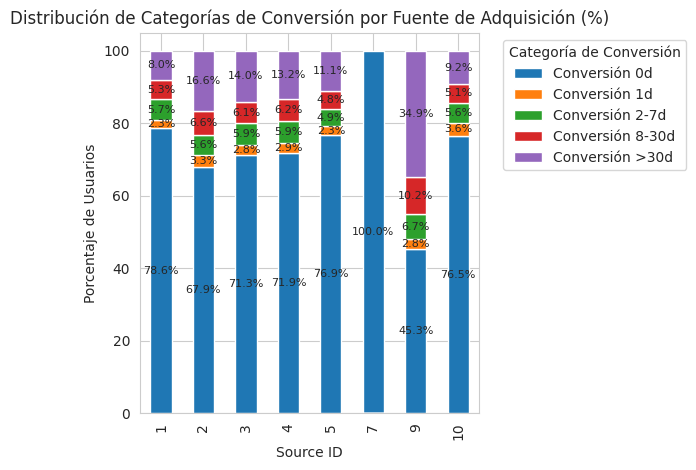

In [59]:
# Crear tabla pivote para categorías de conversión por source_id
pivot_conversiones = conversiones.groupby(['source_id', 'categoria_conversion']).size().unstack(fill_value=0)
pivot_conversiones = pivot_conversiones.div(pivot_conversiones.sum(axis=1), axis=0) * 100  # Normalizar a porcentajes

# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura para la gráfica de barras
plt.figure(figsize=(10, 6))

# Gráfica de barras apiladas
ax = pivot_conversiones.plot(kind='bar', stacked=True)

# Agregar porcentajes dentro de las barras
for i, (index, row) in enumerate(pivot_conversiones.iterrows()):
    cumsum = 0  # Seguimiento de la posición acumulada en la barra apilada
    for col in pivot_conversiones.columns:
        value = row[col]
        if value > 0:  # Mostrar solo porcentajes mayores a 0
            ax.text(i, cumsum + value / 2, f'{value:.1f}%', ha='center', va='center', fontsize=8)
            cumsum += value

# Configurar título y etiquetas
plt.title('Distribución de Categorías de Conversión por Fuente de Adquisición (%)')
plt.xlabel('Source ID')
plt.ylabel('Porcentaje de Usuarios')
plt.legend(title='Categoría de Conversión', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [60]:
# Calcular la distribución de categorías de conversión
dist_conversiones = conversiones['categoria_conversion'].value_counts().reset_index()
dist_conversiones.columns = ['categoria_conversion', 'conteo']

# Calcular el total de usuarios
total_usuarios = dist_conversiones['conteo'].sum()

# Calcular el porcentaje para cada categoría
dist_conversiones['porcentaje'] = (dist_conversiones['conteo'] / total_usuarios * 100).round(2)

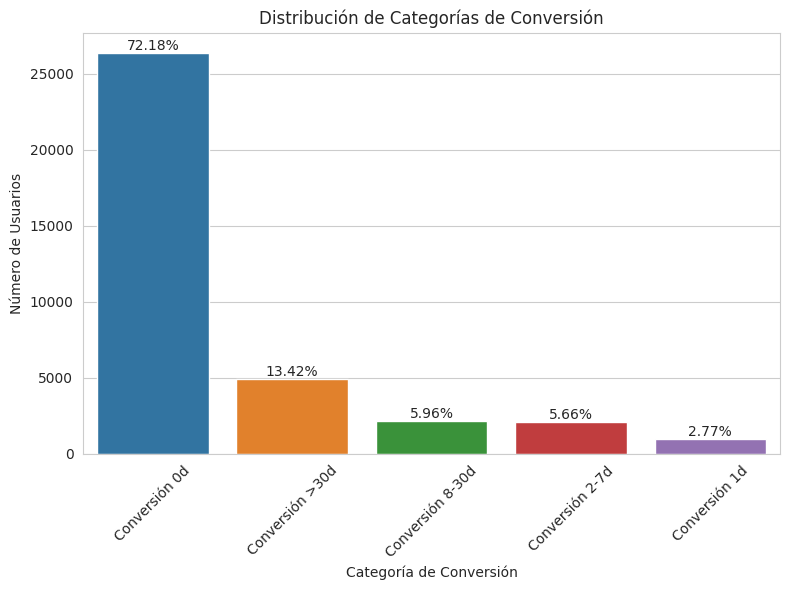

In [61]:
# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura para la gráfica de barras
plt.figure(figsize=(8, 6))

# Gráfica de barras
ax = sns.barplot(data=dist_conversiones, x='categoria_conversion', y='conteo')

# Agregar porcentajes en las barras
for i, row in enumerate(dist_conversiones.itertuples()):
    ax.text(i, row.conteo, f'{row.porcentaje}%', ha='center', va='bottom', fontsize=10)

# Configurar título y etiquetas
plt.title('Distribución de Categorías de Conversión')
plt.xlabel('Categoría de Conversión')
plt.ylabel('Número de Usuarios')
plt.xticks(rotation=45)

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

### Observaciones:

- Sin importar la fuente, la mayoría de los clientes, hicieron su primera compra el mismo día que visitaron la página.
- Las primeras compras que se hicieron el mismo día de la primera visita, representan el 72% del total.
- Las compras que se hicieron al día siguiente de la visita, representan el 2.8%.
- Las compras que se hicieron entre 2 y 7 días depués de la visita, llegan al 5.7%.
- Las compras cuya diferencia entre la visita y la compra, son de entre 8 y 30 días; alcanzan casi un 6% del total.
- Finalmente, las compras realizadas 30 o más días después de la primera visita; abarcan el 13.4% del total.

### 2.2.2 ¿Cuántos pedidos hacen durante un período de tiempo dado?

In [62]:
# Crear columnas para períodos
ordenes['dia'] = ordenes['buy_ts'].dt.date
ordenes['semana'] = ordenes['buy_ts'].dt.isocalendar().week
ordenes['mes'] = ordenes['buy_ts'].dt.to_period('M')

In [63]:
# Contar pedidos por período
pedidos_diarios = ordenes.groupby('dia').size().reset_index(name='num_pedidos')
pedidos_semanales = ordenes.groupby('semana').size().reset_index(name='num_pedidos')
pedidos_mensuales = ordenes.groupby('mes').size().reset_index(name='num_pedidos')

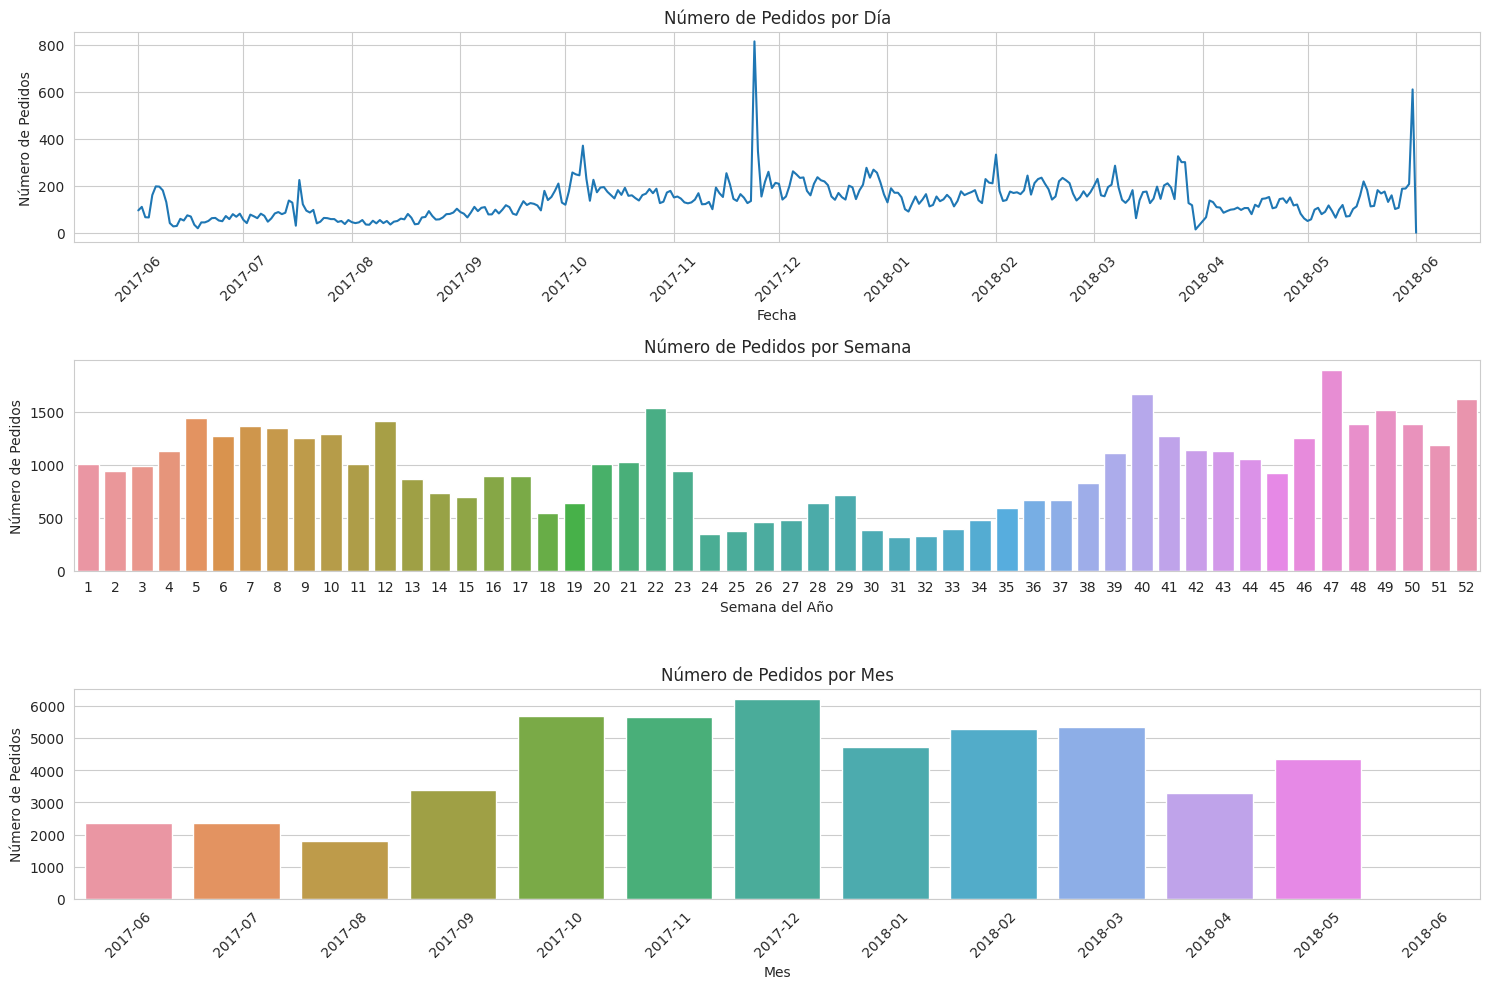

In [64]:
# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura con subplots para los períodos
plt.figure(figsize=(15, 10))

# Gráfica de pedidos diarios
plt.subplot(3, 1, 1)
sns.lineplot(data=pedidos_diarios, x='dia', y='num_pedidos')
plt.title('Número de Pedidos por Día')
plt.xlabel('Fecha')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Gráfica de pedidos semanales
plt.subplot(3, 1, 2)
sns.barplot(data=pedidos_semanales, x='semana', y='num_pedidos')
plt.title('Número de Pedidos por Semana')
plt.xlabel('Semana del Año')
plt.ylabel('Número de Pedidos')

# Gráfica de pedidos mensuales
plt.subplot(3, 1, 3)
sns.barplot(data=pedidos_mensuales, x='mes', y='num_pedidos')
plt.title('Número de Pedidos por Mes')
plt.xlabel('Mes')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45)

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

### Observaciones:
 - La gráfica de pedidos diarios, muestra un pico a finales de noviembre del 2017; quizá son compras para eventos que se llevaron a cabo en la época navideña del mismo año.
 - En la misma gráfica, se ve otro pico a finales de mayo del 2018, quizá son boletos de eventos para el verano del 2018.
 - En la gráfica de pedidos por semana, se observa que las mayores compras caen en las semanas previas a la época navideña y durante la época navideña. Superando los 1000 pedidos e incluso los 1500 pedidos.
 - Las primeras semanas del año, también muestran bastante actividad; con cantidades de entre 1000 y 1500 pedidos semanales.
 - Las semanas del verano, son las semanas con menos acvidad; con alrededor de 500 pedidos semanales. No obstante, se observa un pico en una semana previa al verano, lo que lleva a pensar a la compra de boletos para eventos estivales.
 - Finalmente, en la gráfica por mes; se observa una intensa actividad entre octubre del 2017 y marzo del 2018, con cifras de más de 4000 pedidis por mes. Los eventos durante esos meses, debieron ser muy atractivos para los clientes.

### 2.2.3 ¿Cuál es el tamaño promedio de compra?

In [65]:
# Calcular el tamaño promedio de compra (general)
promedio_general = ordenes['revenue'].mean().round(2)
print("Tamaño promedio de compra en general: $", promedio_general)

Tamaño promedio de compra en general: $ 5.0


In [66]:
# Calcular el tamaño promedio por período
promedio_diario = ordenes.groupby('dia')['revenue'].mean().reset_index(name='promedio_revenue')
promedio_semanal = ordenes.groupby('semana')['revenue'].mean().reset_index(name='promedio_revenue')
promedio_mensual = ordenes.groupby('mes')['revenue'].mean().reset_index(name='promedio_revenue')

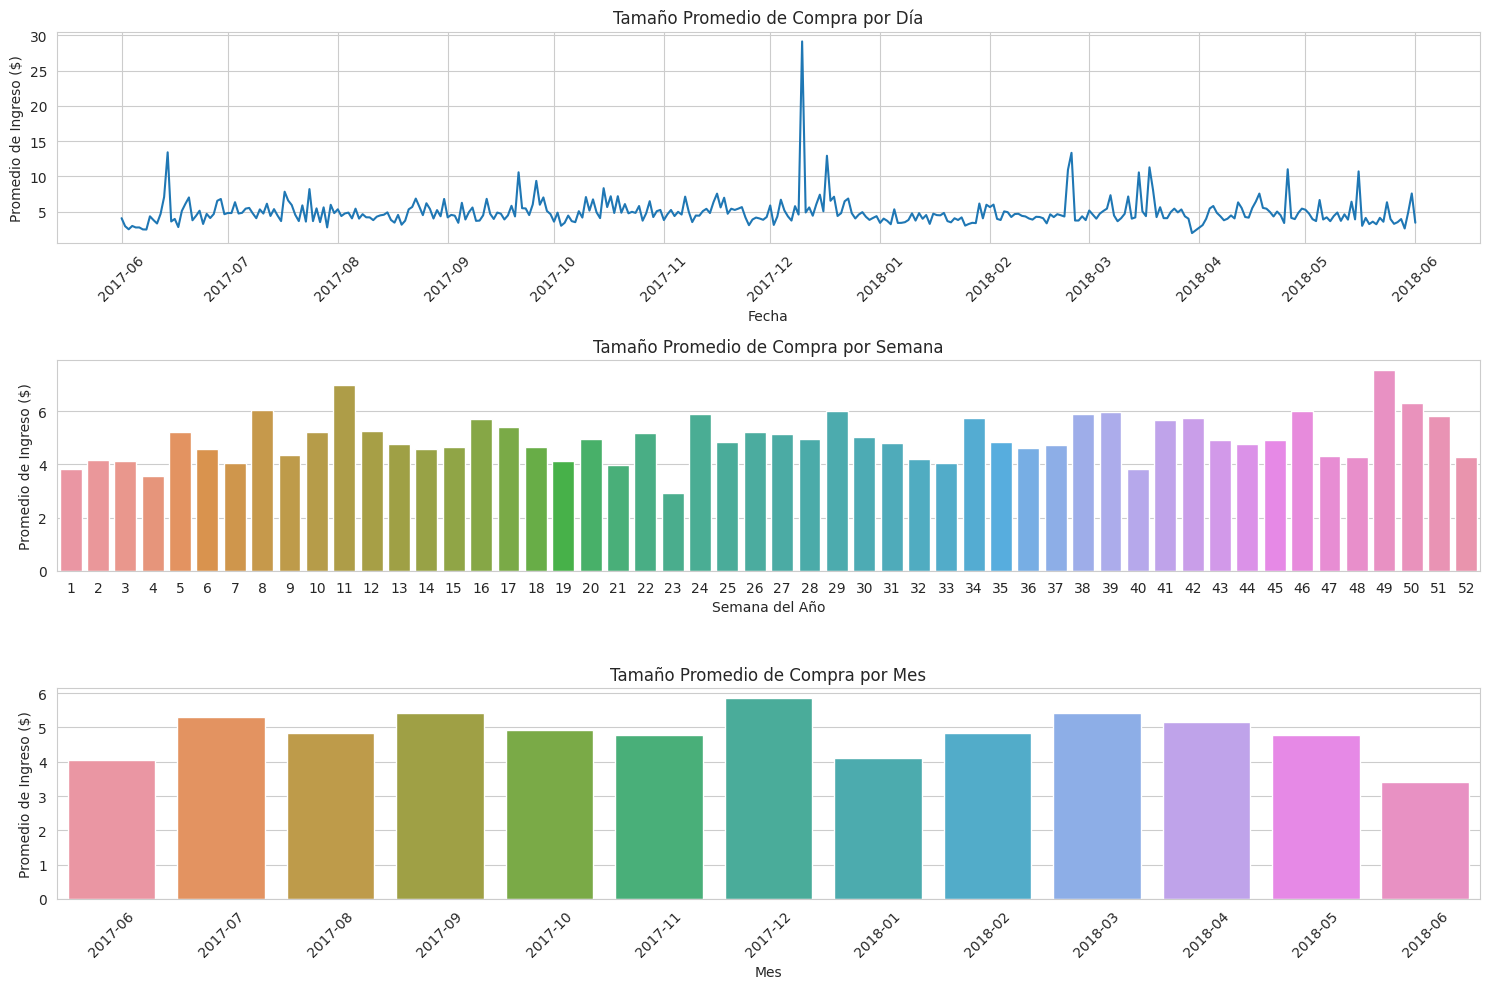

In [67]:
# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura con subplots para los períodos
plt.figure(figsize=(15, 10))

# Gráfica de tamaño promedio diario
plt.subplot(3, 1, 1)
sns.lineplot(data=promedio_diario, x='dia', y='promedio_revenue')
plt.title('Tamaño Promedio de Compra por Día')
plt.xlabel('Fecha')
plt.ylabel('Promedio de Ingreso ($)')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Gráfica de tamaño promedio semanal
plt.subplot(3, 1, 2)
sns.barplot(data=promedio_semanal, x='semana', y='promedio_revenue')
plt.title('Tamaño Promedio de Compra por Semana')
plt.xlabel('Semana del Año')
plt.ylabel('Promedio de Ingreso ($)')

# Gráfica de tamaño promedio mensual
plt.subplot(3, 1, 3)
sns.barplot(data=promedio_mensual, x='mes', y='promedio_revenue')
plt.title('Tamaño Promedio de Compra por Mes')
plt.xlabel('Mes')
plt.ylabel('Promedio de Ingreso ($)')
plt.xticks(rotation=45)

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

### Observaciones:

- Con base en la gráfica de Promedio de Compra por Día, se observa que un pico sobresaliente en el mes de diciembre del 2017; con una compra de caso 30 USD. Lo que coincide con la época navideña.
- En la gráfica de Promedio de Compra por Semana, la compra es relativamente uniforme (entre 4 y 6 USD); no obstante, también se nota que el tamaño de la compra es mayor en las semanas 49 y 50 (más de 6 USD); que también corresponde a la época navideña.
- En la gráfica Promedio de Compra por Mes, nuevamente se corrobora que la época de mayor compra es la navideña; pues el mes de diciembre de 2017 resalta sobre los demás con casi 6 USD.
- En la msma gráfica, se observa que la compra es relativamente uniforme a lo largo de los meses, oscilando entre 3.5 USD y 5.5 USD.
- Finalmente, el promedio del tamaño de la compra general, del periodo de junio del 2017 a junio del 2018, es de 5 USD.

### 2.2.4 ¿Cuánto dinero traen? (LTV)

In [68]:
# Calcular LTV por usuario (suma de revenue por uid)
ltv_por_usuario = ordenes.groupby('uid')['revenue'].sum().reset_index(name='ltv')

In [69]:
# Obtener source_id de la primera visita
primera_visita = visitas.groupby('uid')['start_ts'].min().reset_index()
primera_visita_con_source = pd.merge(
    primera_visita,
    visitas[['uid', 'start_ts', 'source_id']],
    left_on=['uid', 'start_ts'],
    right_on=['uid', 'start_ts'],
    how='left'
)


In [70]:
# Unir LTV con source_id
ltv_con_fuente = pd.merge(ltv_por_usuario, primera_visita_con_source[['uid', 'source_id']], on='uid', how='left')

In [71]:
# Calcular LTV promedio general y por source_id
ltv_promedio_general = ltv_por_usuario['ltv'].mean()
ltv_promedio_por_fuente = ltv_con_fuente.groupby('source_id')['ltv'].mean().reset_index(name='ltv_promedio')

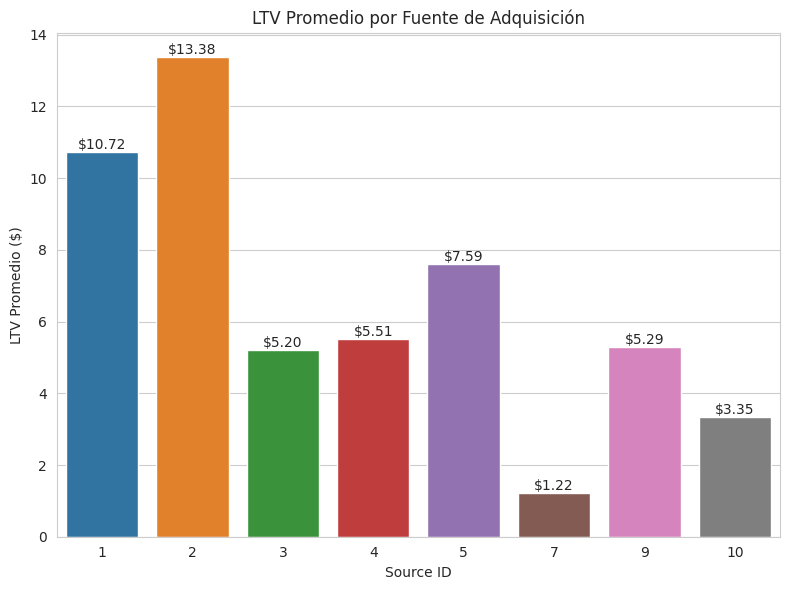

In [72]:
# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura para la gráfica
plt.figure(figsize=(8, 6))

# Gráfica de barras para LTV promedio por source_id
ax = sns.barplot(data=ltv_promedio_por_fuente, x='source_id', y='ltv_promedio')
plt.title('LTV Promedio por Fuente de Adquisición')
plt.xlabel('Source ID')
plt.ylabel('LTV Promedio ($)')

# Agregar valores de LTV en las barras
for i, row in enumerate(ltv_promedio_por_fuente.itertuples()):
    ax.text(i, row.ltv_promedio, f'${row.ltv_promedio:.2f}', ha='center', va='bottom', fontsize=10)

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [73]:
# Mostrar resultados
print(f"LTV promedio general: ${ltv_promedio_general:.2f}")
print("\nLTV promedio por fuente de adquisición:")
print(ltv_promedio_por_fuente)
print("\nResumen estadístico del LTV por usuario:")
print(ltv_por_usuario['ltv'].describe())

LTV promedio general: $6.90

LTV promedio por fuente de adquisición:
   source_id  ltv_promedio
0          1     10.724577
1          2     13.383802
2          3      5.204931
3          4      5.506685
4          5      7.592558
5          7      1.220000
6          9      5.293566
7         10      3.348631

Resumen estadístico del LTV por usuario:
count    36523.000000
mean         6.901328
std         88.128535
min          0.000000
25%          1.470000
50%          3.050000
75%          5.800000
max      11810.180000
Name: ltv, dtype: float64


In [74]:
# Unir LTV con la primera compra para obtener el mes
primera_compra = ordenes.groupby('uid')[['buy_ts','dia','semana', 'mes']].min().reset_index()
ltv_con_periodos = pd.merge(ltv_con_fuente, primera_compra[['uid','dia','semana', 'mes']], on='uid', how='left')

# Calcular LTV promedio por mes y source_id
pivot_mensual = ltv_con_periodos.groupby(['mes', 'source_id'])['ltv'].mean().unstack(fill_value=0)

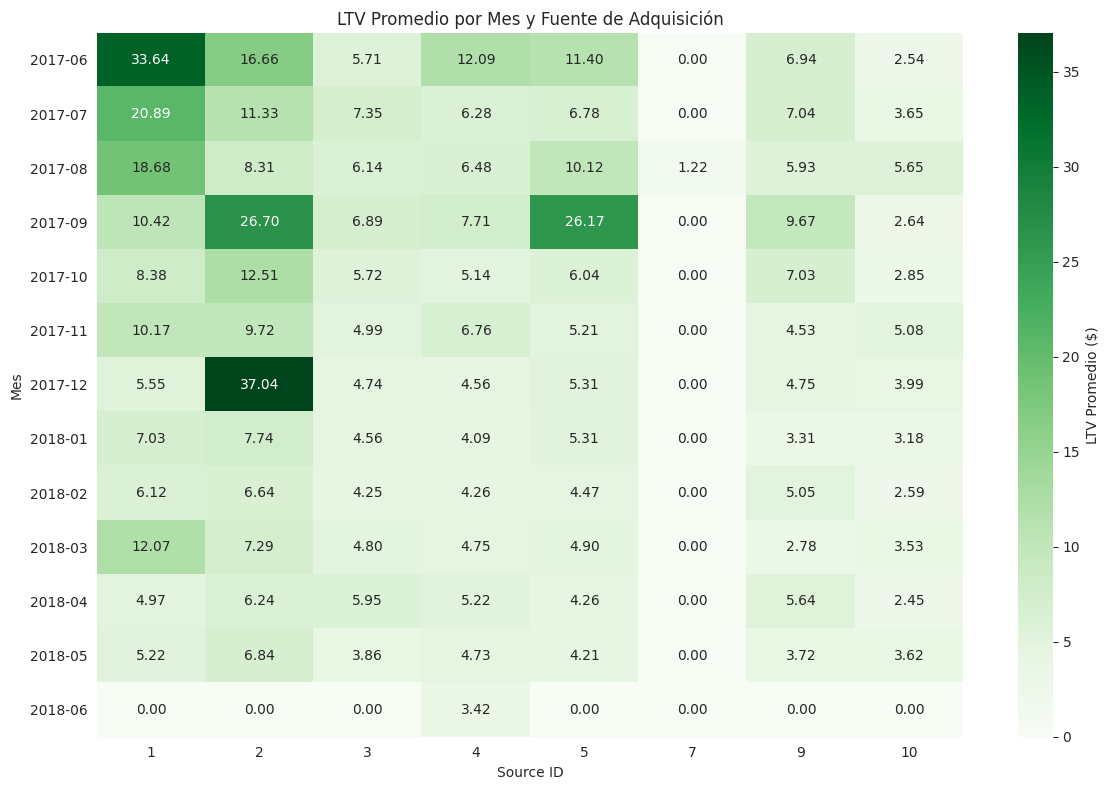

In [75]:
# Heatmap para LTV por mes y source_id
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_mensual, annot=True, fmt='.2f', cmap='Greens', cbar_kws={'label': 'LTV Promedio ($)'})
plt.title('LTV Promedio por Mes y Fuente de Adquisición')
plt.xlabel('Source ID')
plt.ylabel('Mes')
plt.tight_layout()
plt.show()

### Observaciones:

- El LTV promedio general del periodo de junio 2017 a junio 2018 es de **6.90 USD**.
- El LTV por fuente (*source*) muestra que las fuentes 2 y 1 son las que más dinero ingresaron, con **13.38** y **10.72** dólares, respectivamente.
- La fuente 5 también tuvo un ingreso por encima del promedio, con **7.59 USD**.
- El resto de las fuentes tuvo ingresos por debajo del promedio. Llama la atención la fuente 7, que solo ingresó **1.22 USD**.
- Al observar los ingresos por fuente y por mes (mapa de calor), se corrobora que las fuentes 2 y 1 son las más activas, seguidas de la fuente 5.
- Para el caso de la fuente 7, se observa que solo tuvo ingresos en el mes de agosto del 2018; los demás meses estuvo en cero.
- No hay registros de ingresos de las fuentes 6 y 8.
- El resto de las fuentes tienen ingresos alrededor del promedio general.

## 2.3 Marketing

### 2.3.1 ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo) 

In [76]:
# Calcular gasto total
gasto_total = costos['costs'].sum()

# Calcular gastos por fuente
gastos_por_fuente = costos.groupby('source_id')['costs'].sum().reset_index(name='gastos')

In [77]:
# Crear columnas para períodos
costos['dia'] = costos['dt'].dt.date
costos['semana'] = costos['dt'].dt.isocalendar().week
costos['mes'] = costos['dt'].dt.to_period('M')

In [78]:
# Calcular gastos por período
gastos_diarios = costos.groupby('dia')['costs'].sum().reset_index(name='gastos')
gastos_semanales = costos.groupby('semana')['costs'].sum().reset_index(name='gastos')
gastos_mensuales = costos.groupby('mes')['costs'].sum().reset_index(name='gastos')


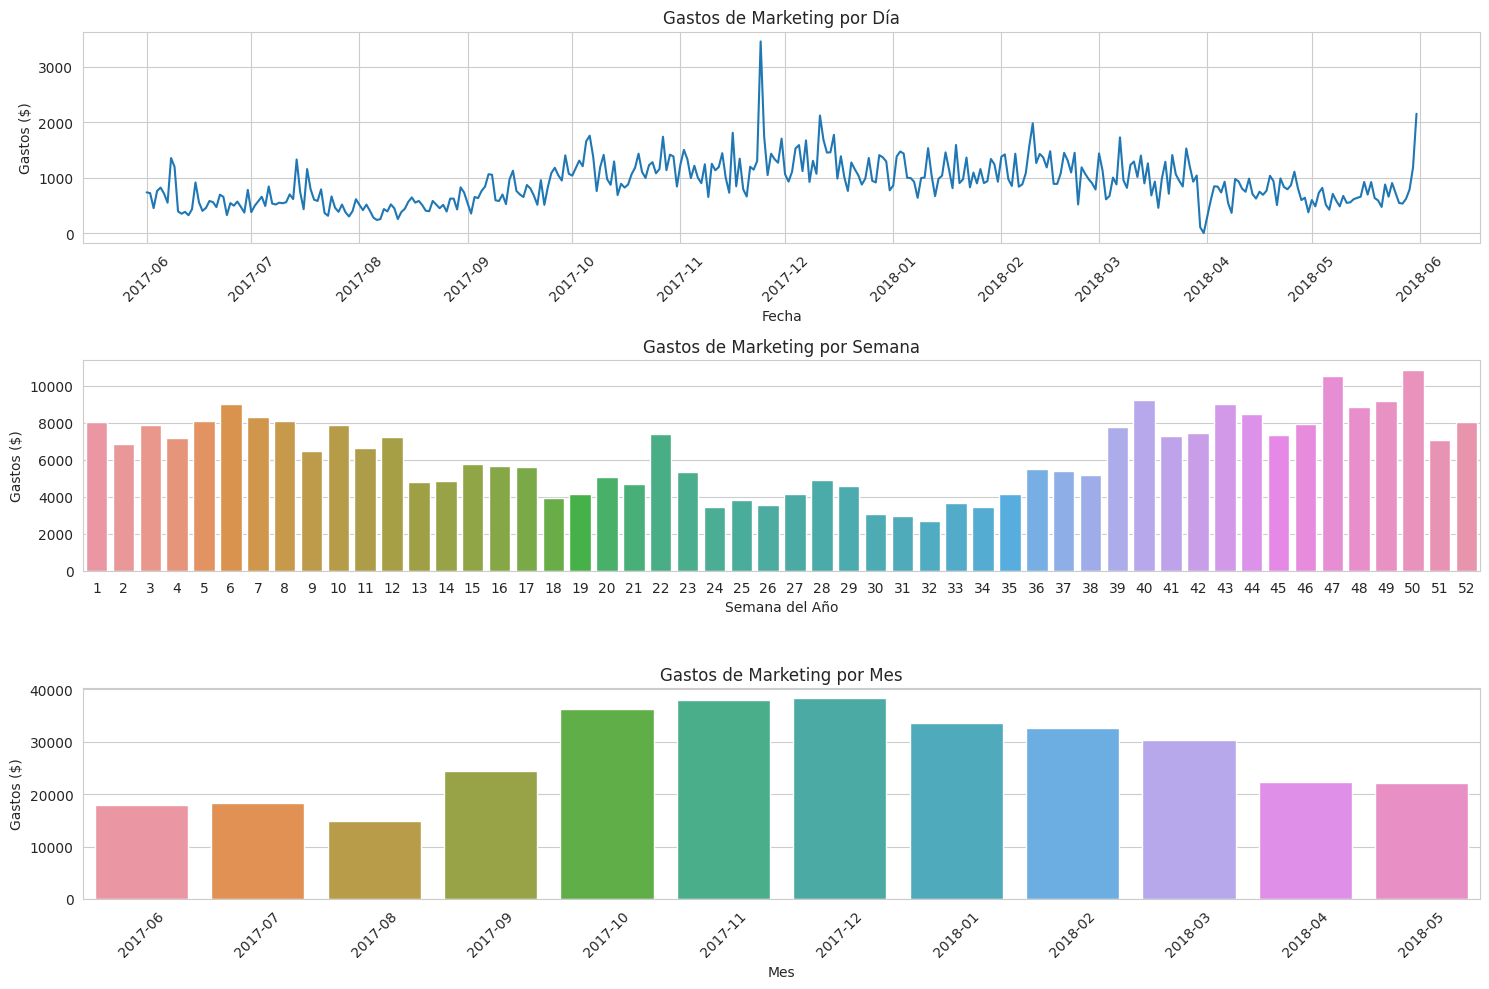

In [79]:
# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura con subplots para los períodos
plt.figure(figsize=(15, 10))

# Gráfica de gastos diarios
plt.subplot(3, 1, 1)
sns.lineplot(data=gastos_diarios, x='dia', y='gastos')
plt.title('Gastos de Marketing por Día')
plt.xlabel('Fecha')
plt.ylabel('Gastos ($)')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Gráfica de gastos semanales
plt.subplot(3, 1, 2)
sns.barplot(data=gastos_semanales, x='semana', y='gastos')
plt.title('Gastos de Marketing por Semana')
plt.xlabel('Semana del Año')
plt.ylabel('Gastos ($)')

# Gráfica de gastos mensuales
plt.subplot(3, 1, 3)
sns.barplot(data=gastos_mensuales, x='mes', y='gastos')
plt.title('Gastos de Marketing por Mes')
plt.xlabel('Mes')
plt.ylabel('Gastos ($)')
plt.xticks(rotation=45)

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

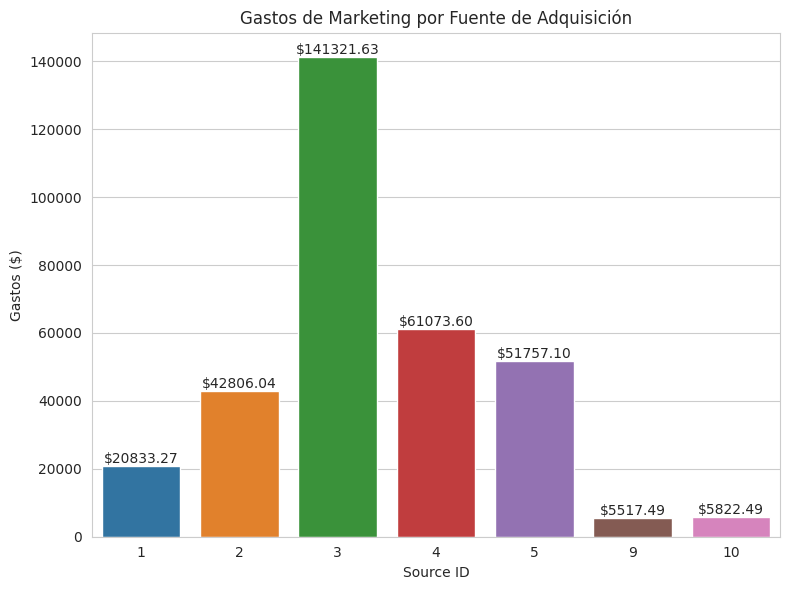

In [80]:
# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura para la gráfica de barras
plt.figure(figsize=(8, 6))

# Gráfica de barras para gastos por source_id
ax = sns.barplot(data=gastos_por_fuente, x='source_id', y='gastos')

# Agregar valores de gastos en las barras
for i, row in enumerate(gastos_por_fuente.itertuples()):
    ax.text(i, row.gastos, f'${row.gastos:.2f}', ha='center', va='bottom', fontsize=10)

# Configurar título y etiquetas
plt.title('Gastos de Marketing por Fuente de Adquisición')
plt.xlabel('Source ID')
plt.ylabel('Gastos ($)')

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [81]:
# Mostrar resultados
print(f"Gasto total en marketing: ${gasto_total:.2f}")
print("\nGastos por fuente de adquisición:")
print(gastos_por_fuente)
print("\nResumen de gastos diarios:")
print(gastos_diarios.describe())
print("\nResumen de gastos semanales:")
print(gastos_semanales.describe())
print("\nResumen de gastos mensuales:")
print(gastos_mensuales.describe())

Gasto total en marketing: $329131.62

Gastos por fuente de adquisición:
   source_id     gastos
0          1   20833.27
1          2   42806.04
2          3  141321.63
3          4   61073.60
4          5   51757.10
5          9    5517.49
6         10    5822.49

Resumen de gastos diarios:
            gastos
count   364.000000
mean    904.207747
std     396.956825
min       0.700000
25%     595.682500
50%     873.655000
75%    1155.605000
max    3458.860000

Resumen de gastos semanales:
          semana        gastos
count  52.000000     52.000000
mean   26.500000   6329.454231
std    15.154757   2100.725763
min     1.000000   2677.790000
25%    13.750000   4680.600000
50%    26.500000   6570.925000
75%    39.250000   7981.892500
max    52.000000  10861.580000

Resumen de gastos mensuales:
             gastos
count     12.000000
mean   27427.635000
std     8405.071207
min    14790.540000
25%    21228.350000
50%    27392.090000
75%    34219.610000
max    38315.350000


### Observaciones:

- El gasto total fue de 3,291,31.62 USD.
- El mayor gasto se hizo en la fuente 3 con 141,321.63 USD.
- No hay registros de gastos en las fuentes 6, 7, y 8.
- Por tiempo, en gasto diario; el mayor gasto se hizo a finales de noviembre del 2017.
- Hay un segundo gasto sobresaliente el último día de mayo del 2018.
- Al revisar el gasto por semana del año, estos se concentran en las primeras semanas (invierno) y en las últimas (otoño-invierno).
- En las semanas de primavera y verano, el gasto es menor.
- Por mes, los gastos más fuertes se distribuyen entre octubre del 2017 y febrero del 2018; con gastos que superan los 30 mil dólares mensuales.
- Los menores gastos corresponden a junio, julio y agosto del 2018, con menos de 20 mil dólares cada uno.

### 2.3.2 ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

In [82]:
# Contar clientes (usuarios con al menos una compra) por source_id
clientes_por_fuente = conversiones.groupby('source_id')['uid'].nunique().reset_index(name='num_clientes')

# Unir gastos y clientes por fuente
cac_por_fuente = pd.merge(clientes_por_fuente ,gastos_por_fuente, on='source_id', how='left').fillna(0)

In [83]:
# Calcular CAC (gastos / número de clientes)
cac_por_fuente['cac'] =( cac_por_fuente['gastos'] / cac_por_fuente['num_clientes']).round(2)

In [84]:
cac_por_fuente

,source_id,num_clientes,gastos,cac
0,1,2899,20833.27,7.19
1,2,3506,42806.04,12.21
2,3,10473,141321.63,13.49
3,4,10296,61073.60,5.93
4,5,6931,51757.10,7.47
5,7,1,0.00,0.00
6,9,1088,5517.49,5.07
7,10,1329,5822.49,4.38


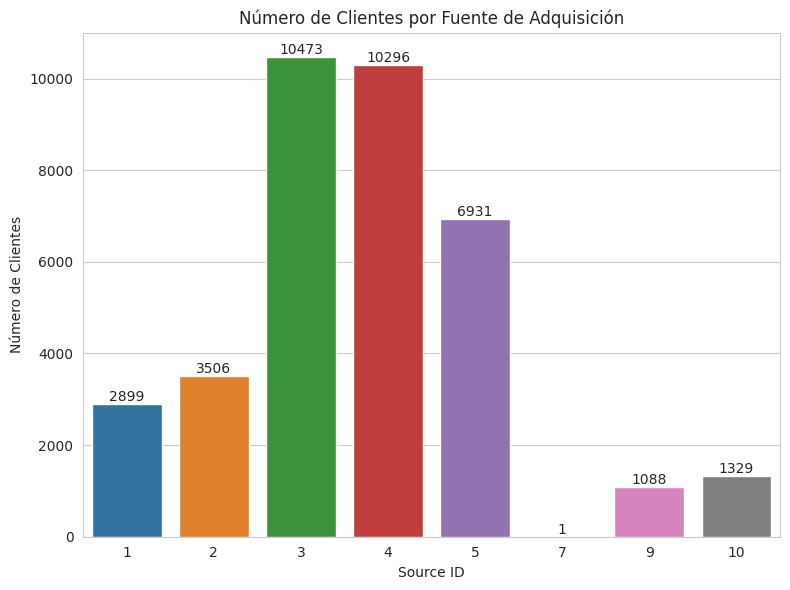

In [85]:
# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura para la gráfica de barras
plt.figure(figsize=(8, 6))

# Gráfica de barras para clientes por source_id
ax = sns.barplot(data=clientes_por_fuente, x='source_id', y='num_clientes')

# Agregar valores de clientes en las barras
for i, row in enumerate(clientes_por_fuente.itertuples()):
    ax.text(i, row.num_clientes, f'{row.num_clientes}', ha='center', va='bottom', fontsize=10)

# Configurar título y etiquetas
plt.title('Número de Clientes por Fuente de Adquisición')
plt.xlabel('Source ID')
plt.ylabel('Número de Clientes')

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

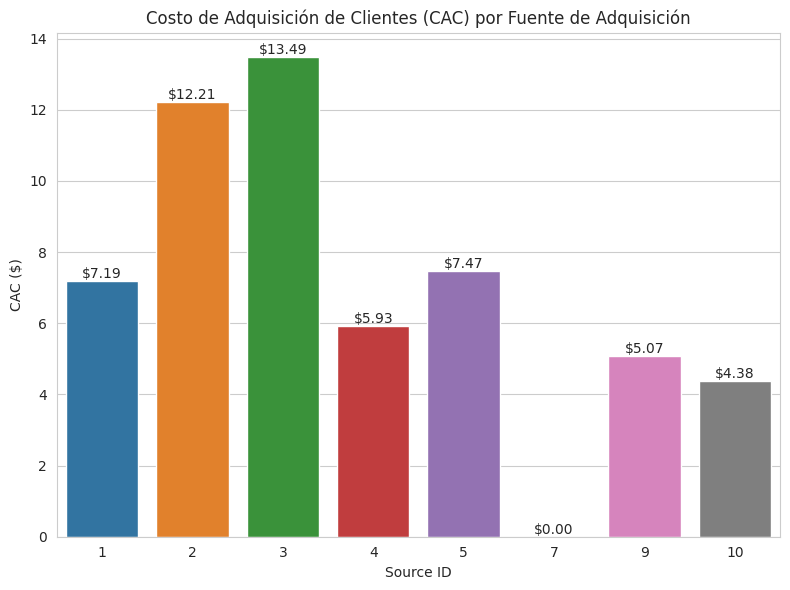

In [86]:
# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura para la gráfica de barras
plt.figure(figsize=(8, 6))

# Gráfica de barras para CAC por source_id
ax = sns.barplot(data=cac_por_fuente, x='source_id', y='cac')

# Agregar valores de CAC en las barras
for i, row in enumerate(cac_por_fuente.itertuples()):
    ax.text(i, row.cac, f'${row.cac:.2f}', ha='center', va='bottom', fontsize=10)

# Configurar título y etiquetas
plt.title('Costo de Adquisición de Clientes (CAC) por Fuente de Adquisición')
plt.xlabel('Source ID')
plt.ylabel('CAC ($)')

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [87]:
# Mostrar resultados
print("CAC por fuente de adquisición:")
print(cac_por_fuente[['source_id', 'gastos', 'num_clientes', 'cac']])
print("\nResumen estadístico del CAC:")
print(cac_por_fuente['cac'].describe())

CAC por fuente de adquisición:
   source_id     gastos  num_clientes    cac
0          1   20833.27          2899   7.19
1          2   42806.04          3506  12.21
2          3  141321.63         10473  13.49
3          4   61073.60         10296   5.93
4          5   51757.10          6931   7.47
5          7       0.00             1   0.00
6          9    5517.49          1088   5.07
7         10    5822.49          1329   4.38

Resumen estadístico del CAC:
count     8.000000
mean      6.967500
std       4.313549
min       0.000000
25%       4.897500
50%       6.560000
75%       8.655000
max      13.490000
Name: cac, dtype: float64


### Observaciones:

- Las fuentes 2 y 3 presentan los CAC más altos, con 12.21 y 13.49 usd respectivamente.
- La fuente 7 tiene un CAC de 0 dólares, dado que no se invirtió en esa fuente.
- El promedio de CAC en general, es de 6.97 usd.

### 2.3.3 ¿Cuán rentables eran las inversiones? (ROMI)

In [88]:
# Calcular ingresos totales por fuente
ingresos_por_fuente = ltv_con_fuente.groupby('source_id')['ltv'].sum().reset_index(name='ingresos')

# Unir ingresos y gastos por fuente
romi_por_fuente = (pd.merge(ingresos_por_fuente, gastos_por_fuente, on='source_id', how='outer')).fillna(0)

In [89]:
# Calcular ROMI: (ingresos - gastos) / gastos * 100
romi_por_fuente['romi'] = ((romi_por_fuente['ingresos'] - romi_por_fuente['gastos']) / romi_por_fuente['gastos'] * 100).round(2)

In [90]:
# Manejar casos donde gastos=0 (ROMI indefinido o NaN)
romi_por_fuente['romi'] = romi_por_fuente['romi'].fillna(0).replace(np.inf, 0)

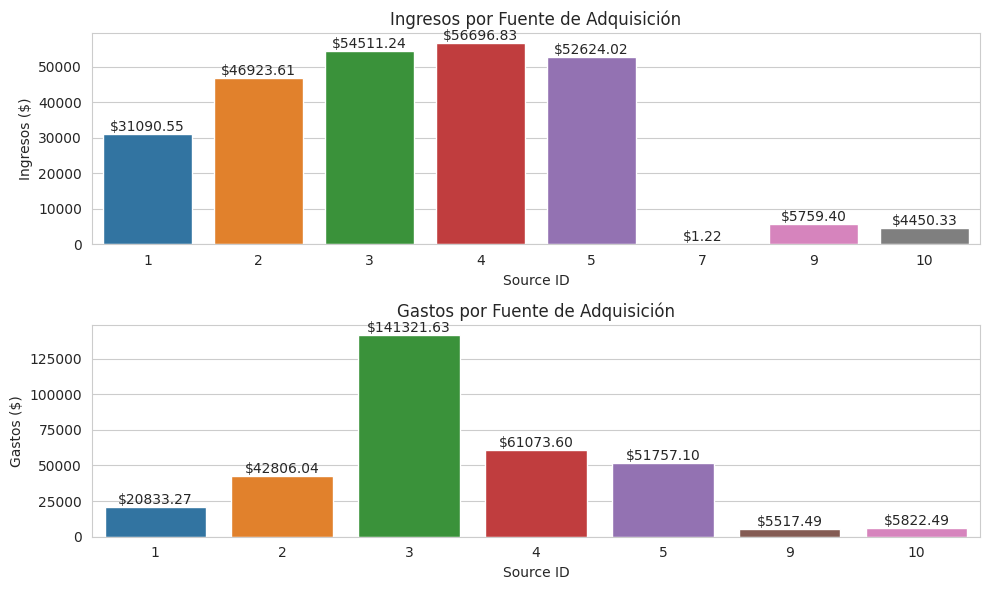

In [91]:
# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura con subplots
plt.figure(figsize=(10, 6))

# Subplot para ingresos por fuente
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=ingresos_por_fuente, x='source_id', y='ingresos')
for i, row in enumerate(ingresos_por_fuente.itertuples()):
    ax1.text(i, row.ingresos, f'${row.ingresos:.2f}', ha='center', va='bottom', fontsize=10)
plt.title('Ingresos por Fuente de Adquisición')
plt.xlabel('Source ID')
plt.ylabel('Ingresos ($)')

# Subplot para gastos por fuente
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=gastos_por_fuente, x='source_id', y='gastos')
for i, row in enumerate(gastos_por_fuente.itertuples()):
    ax2.text(i, row.gastos, f'${row.gastos:.2f}', ha='center', va='bottom', fontsize=10)
plt.title('Gastos por Fuente de Adquisición')
plt.xlabel('Source ID')
plt.ylabel('Gastos ($)')

# Ajustar el diseño
plt.tight_layout()

# Mostrar los gráficos
plt.show()

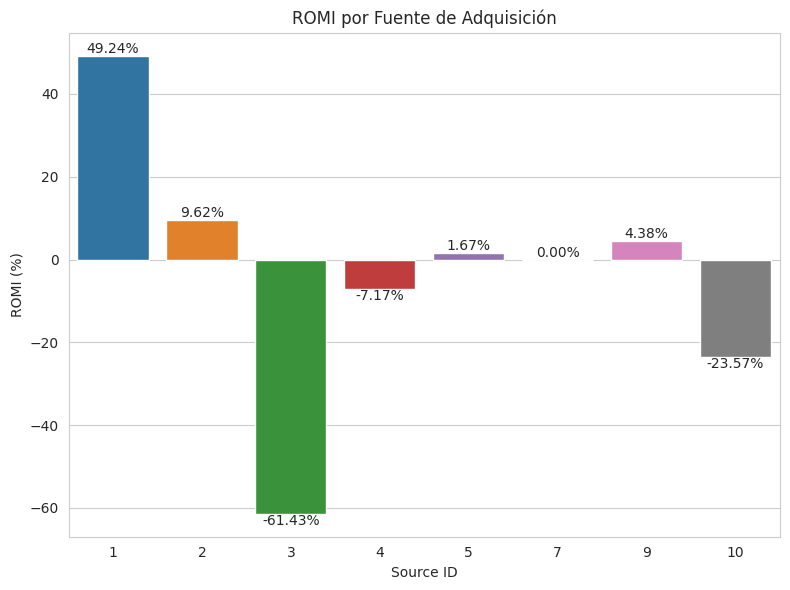

In [92]:
# Crear figura para la gráfica de barras
plt.figure(figsize=(8, 6))

# Gráfica de barras para ROMI por source_id
ax = sns.barplot(data=romi_por_fuente, x='source_id', y='romi')

# Agregar valores de ROMI en las barras
for i, row in enumerate(romi_por_fuente.itertuples()):
    ax.text(i, row.romi, f'{row.romi:.2f}%', ha='center', va='bottom' if row.romi >= 0 else 'top', fontsize=10)

# Configurar título y etiquetas
plt.title('ROMI por Fuente de Adquisición')
plt.xlabel('Source ID')
plt.ylabel('ROMI (%)')

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

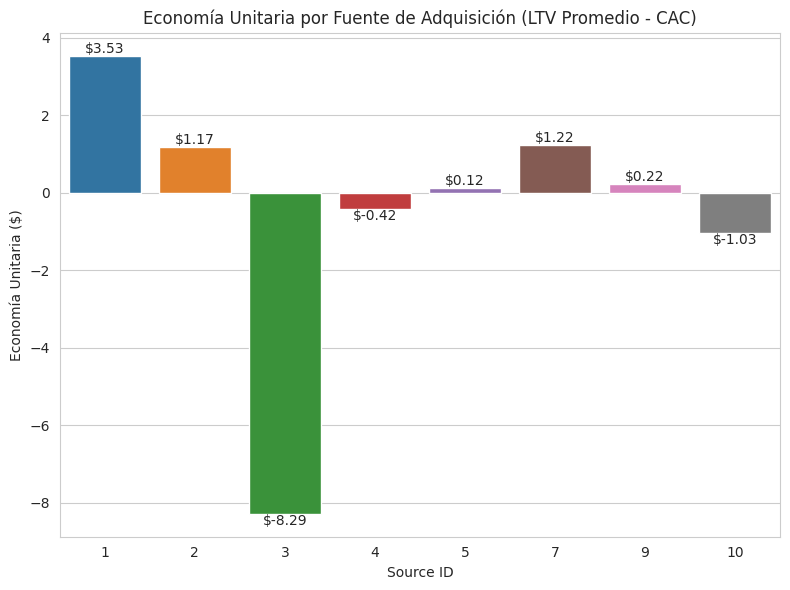

Economía unitaria por fuente de adquisición:
   source_id  ltv_promedio    cac  economia_unitaria
0          1     10.724577   7.19           3.534577
1          2     13.383802  12.21           1.173802
2          3      5.204931  13.49          -8.285069
3          4      5.506685   5.93          -0.423315
4          5      7.592558   7.47           0.122558
5          7      1.220000   0.00           1.220000
6          9      5.293566   5.07           0.223566
7         10      3.348631   4.38          -1.031369

Resumen estadístico de la economía unitaria:
count    8.000000
mean    -0.433156
std      3.460156
min     -8.285069
25%     -0.575329
50%      0.173062
75%      1.185352
max      3.534577
Name: economia_unitaria, dtype: float64


In [93]:
# Unir cac_por_fuente con ingresos_por_fuente para agregar la columna ingresos
cac_por_fuente = pd.merge(cac_por_fuente, ingresos_por_fuente[['source_id', 'ingresos']], on='source_id', how='left')

# Reemplazar valores NaN en ingresos con 0 (para fuentes sin ingresos)
cac_por_fuente['ingresos'] = cac_por_fuente['ingresos'].fillna(0)

# Calcular LTV promedio por fuente (ingresos / num_clientes)
cac_por_fuente['ltv_promedio'] = cac_por_fuente['ingresos'] / cac_por_fuente['num_clientes']

# Calcular economía unitaria por fuente (LTV promedio - CAC)
cac_por_fuente['economia_unitaria'] = cac_por_fuente['ltv_promedio'] - cac_por_fuente['cac']

# Reemplazar NaN con 0 (si no hay clientes)
cac_por_fuente['economia_unitaria'] = cac_por_fuente['economia_unitaria'].fillna(0)

# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura para la gráfica de barras
plt.figure(figsize=(8, 6))

# Gráfica de barras para economía unitaria por source_id
ax = sns.barplot(data=cac_por_fuente, x='source_id', y='economia_unitaria')

# Agregar valores en las barras
for i, row in enumerate(cac_por_fuente.itertuples()):
    ax.text(i, row.economia_unitaria, f'${row.economia_unitaria:.2f}', ha='center', va='bottom' if row.economia_unitaria >= 0 else 'top', fontsize=10)

# Configurar título y etiquetas
plt.title('Economía Unitaria por Fuente de Adquisición (LTV Promedio - CAC)')
plt.xlabel('Source ID')
plt.ylabel('Economía Unitaria ($)')

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# Mostrar resultados
print("Economía unitaria por fuente de adquisición:")
print(cac_por_fuente[['source_id', 'ltv_promedio', 'cac', 'economia_unitaria']])
print("\nResumen estadístico de la economía unitaria:")
print(cac_por_fuente['economia_unitaria'].describe())

In [94]:
# Mostrar resultados
print("ROMI por fuente de adquisición:")
print(romi_por_fuente)
print("\nResumen estadístico del ROMI:")
print(romi_por_fuente['romi'].describe())

ROMI por fuente de adquisición:
   source_id  ingresos     gastos   romi
0          1  31090.55   20833.27  49.24
1          2  46923.61   42806.04   9.62
2          3  54511.24  141321.63 -61.43
3          4  56696.83   61073.60  -7.17
4          5  52624.02   51757.10   1.67
5          7      1.22       0.00   0.00
6          9   5759.40    5517.49   4.38
7         10   4450.33    5822.49 -23.57

Resumen estadístico del ROMI:
count     8.00000
mean     -3.40750
std      31.22912
min     -61.43000
25%     -11.27000
50%       0.83500
75%       5.69000
max      49.24000
Name: romi, dtype: float64


### Observaciones:

- La fuente 1 es la más rentable, con una economía uinitaria de 3.53 USD y un ROMI del 49.24%.
- La fuente 2 es la segunda en rentabilidad, con una economía unitaria de 1.17 USD y un ROMI del 9.62%
- Las fuentes 3, 4 y 10 NO son rentables, pues generan pérdidas; siendo la 10 la que maoyores pérdidas genera (ecnomía unitaria = -8.29 USD y ROMI = -64.43%)
- Las fuentes 5,7 y 9 son rentables, pero su rendimiento es bajo; con economías unitarias menores a 1.5 USD y ROMI menor al 5%.

# 3 Conclusión y recomendaciones

## 3.1 Punto de equilibrio para las fuentes con rendimiento positivo

In [95]:
# Filtrar fuentes con economía unitaria positiva
fuentes_positivas = cac_por_fuente[cac_por_fuente['economia_unitaria'] > 0].copy()

# Calcular punto de equilibrio: gastos / ltv_promedio
fuentes_positivas['punto_equilibrio'] = fuentes_positivas['gastos'] / fuentes_positivas['ltv_promedio']

# Redondear a entero (número de clientes) y manejar NaN/inf con 0
fuentes_positivas['punto_equilibrio'] = fuentes_positivas['punto_equilibrio'].fillna(0).replace(np.inf, 0).round(0).astype(int)

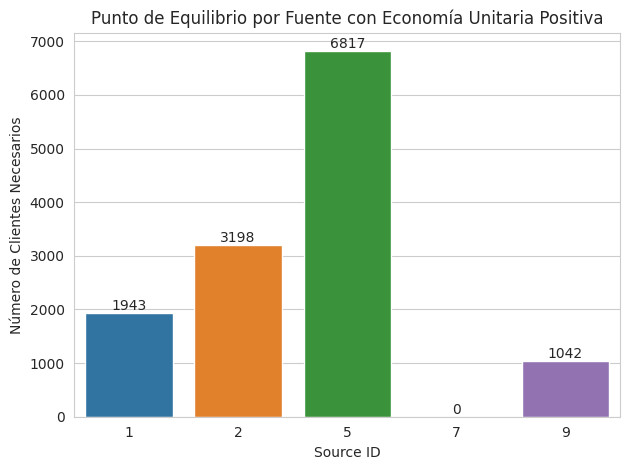

In [96]:
# Gráfica de barras para punto de equilibrio por source_id
ax = sns.barplot(data=fuentes_positivas, x='source_id', y='punto_equilibrio')

# Agregar valores en las barras
for i, row in enumerate(fuentes_positivas.itertuples()):
    ax.text(i, row.punto_equilibrio, f'{row.punto_equilibrio}', ha='center', va='bottom', fontsize=10)

# Configurar título y etiquetas
plt.title('Punto de Equilibrio por Fuente con Economía Unitaria Positiva')
plt.xlabel('Source ID')
plt.ylabel('Número de Clientes Necesarios')

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [97]:
# Mostrar resultados
print("Punto de equilibrio por fuente con economía unitaria positiva:")
print(fuentes_positivas[['source_id', 'gastos', 'ltv_promedio', 'economia_unitaria', 'punto_equilibrio']])

Punto de equilibrio por fuente con economía unitaria positiva:
   source_id    gastos  ltv_promedio  economia_unitaria  punto_equilibrio
0          1  20833.27     10.724577           3.534577              1943
1          2  42806.04     13.383802           1.173802              3198
4          5  51757.10      7.592558           0.122558              6817
5          7      0.00      1.220000           1.220000                 0
6          9   5517.49      5.293566           0.223566              1042


## 3.2 Proyecciones de inversión.

In [98]:
# Definir función corregida para proyecciones por fuente
def proyeccion_por_fuente(source_id, nuevo_presupuesto, cac_por_fuente):
    # Obtener métricas actuales de la fuente
    fuente_data = cac_por_fuente[cac_por_fuente['source_id'] == source_id]
    if fuente_data.empty:
        return {
            'source_id': source_id,
            'presupuesto': nuevo_presupuesto,
            'usuarios_nuevos': 0,
            'revenue_proyectado': 0,
            'beneficio_proyectado': 0,
            'romi_proyectado': 0
        }
    
    cac_actual = fuente_data['cac'].iloc[0]
    ltv_actual = fuente_data['ltv_promedio'].iloc[0]
    
    # Manejar caso de cac=0 (fuente 7)
    if cac_actual == 0:
        # Para fuente orgánica, no hay usuarios nuevos ni ingresos por presupuesto
        usuarios_nuevos = 0
        revenue_proyectado = 0
        beneficio_proyectado = 0
        romi_proyectado = 0  # ROMI indefinido, se asigna 0
    else:
        # Proyectar usuarios nuevos
        usuarios_nuevos = nuevo_presupuesto / cac_actual
        # Proyectar ingresos
        revenue_proyectado = usuarios_nuevos * ltv_actual
        # Calcular beneficio proyectado
        beneficio_proyectado = revenue_proyectado - nuevo_presupuesto
        # Calcular ROMI proyectado (manejar presupuesto=0)
        romi_proyectado = (beneficio_proyectado / nuevo_presupuesto * 100) if nuevo_presupuesto > 0 else 0
    
    return {
        'source_id': source_id,
        'presupuesto': nuevo_presupuesto,
        'usuarios_nuevos': usuarios_nuevos,
        'revenue_proyectado': revenue_proyectado,
        'beneficio_proyectado': beneficio_proyectado,
        'romi_proyectado': romi_proyectado
    }

In [99]:
# Crear lista para almacenar proyecciones
proyecciones = []

# Lista de fuentes a proyectar (todas en cac_por_fuente)
fuentes = cac_por_fuente['source_id'].unique()

# Probar diferentes presupuestos para cada fuente
for source in fuentes:
    for presupuesto in [50000, 100000, 150000, 200000]:
        resultado = proyeccion_por_fuente(source, presupuesto, cac_por_fuente)
        proyecciones.append(resultado)

# Convertir proyecciones a dataframe
proyecciones_beneficio = pd.DataFrame(proyecciones)


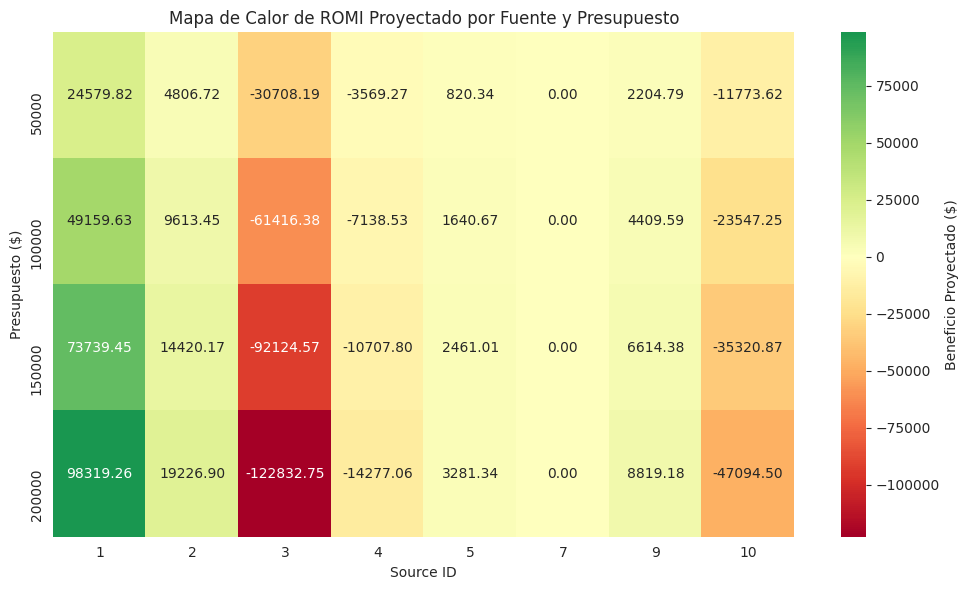

In [100]:
# Crear tabla pivote para el mapa de calor
pivot_romi = proyecciones_beneficio.pivot_table(index='presupuesto', columns='source_id', values='beneficio_proyectado', aggfunc='mean').round(2)

# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura para el mapa de calor
plt.figure(figsize=(10, 6))

# Generar mapa de calor
sns.heatmap(pivot_romi, annot=True, fmt='.2f', cmap='RdYlGn', cbar_kws={'label': 'Beneficio Proyectado ($)'}, center=0)

# Configurar título y etiquetas
plt.title('Mapa de Calor de ROMI Proyectado por Fuente y Presupuesto')
plt.xlabel('Source ID')
plt.ylabel('Presupuesto ($)')

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

## 3.3 Ingresos y gastos en general

In [101]:
#Ingresos totales
ingresos_totales = romi_por_fuente['ingresos'].sum().round(2)
print("Ingresos totales: $", ingresos_totales)

Ingresos totales: $ 252057.2


In [102]:
#Gastos totales
gastos_totales = romi_por_fuente['gastos'].sum().round(2)
print("Gastos totales: $", gastos_totales)

Gastos totales: $ 329131.62


In [105]:
#Beneficio neto
beneficio_neto = ingresos_totales -  gastos_totales
print("Beneficio neto: $", beneficio_neto)

Beneficio neto: $ -77074.41999999998


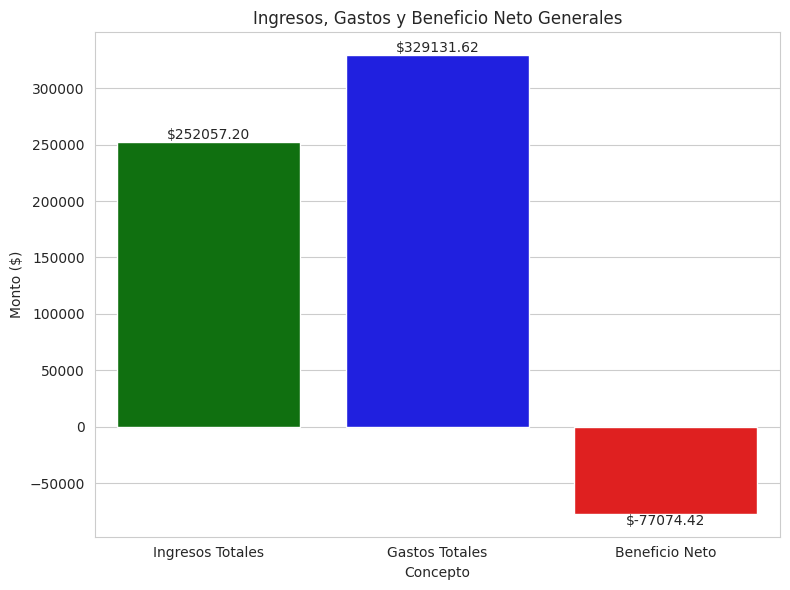

In [110]:
# Crear dataframe para graficar
resultados_negocio = pd.DataFrame({
    'Concepto': ['Ingresos Totales', 'Gastos Totales', 'Beneficio Neto'],
    'Monto': [ingresos_totales, gastos_totales, beneficio_neto]
})

# Configurar el estilo del gráfico
sns.set_style("whitegrid")

# Crear figura para la gráfica de barras
plt.figure(figsize=(8, 6))

# Graficar barras
ax = sns.barplot(data=resultados_negocio, x='Concepto', y='Monto', palette=['green', 'blue', 'red'])

# Agregar valores encima de las barras
for i, row in enumerate(resultados_negocio.itertuples()):
    ax.text(i, row.Monto, f'${row.Monto:.2f}', ha='center', va='bottom' if row.Monto >= 0 else 'top', fontsize=10)

# Configurar título y etiquetas
plt.title('Ingresos, Gastos y Beneficio Neto Generales')
plt.xlabel('Concepto')
plt.ylabel('Monto ($)')

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# Conclusión:
#### El negocio inviertió en publicidad por diferentes fuentes para atraer clientes, aún cuando todas las fuentes atrajeron clientes y tuvieron ingresos; sólo dos fuentes (1 y 2) dieron rendimientos significativos (49% y 9% respectivamente); mientras que hasta 3 fuentes (3, 4 y 10) generaron pérdidas, siendo la fuente 3 la que resultó en las mayores pérdidas (-61%); las otras tres fuentes tuvieron rendimientos positivos, pero muy bajos (<5%). El negocio vió una pérdida neta (77 mil dólares), debido al gasto en inversión en las fuentes con rendimiento negativo.

# Recomendaciones:
#### - Evitar las fuentes 3, 4 y 10 por sus ROMI negativos.
#### - Concentrar las inversiones de marketing en las fuentes 1 y 2, principalmente en la 1 (ROMI del 49%). Dado que son las fuentes que más beneficios dejan (ver la tabla de proyecciones).

#### - Reorientar las inversiones en las fuentes 5 y 9 (ROMI > 5%) a las fuentes 1 y 2.
#### - Hechar un vistazo a la fuente 7, que parece ser orgánica; ya que tuvo un pequeño ingreso sin gasto en marketing.